# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

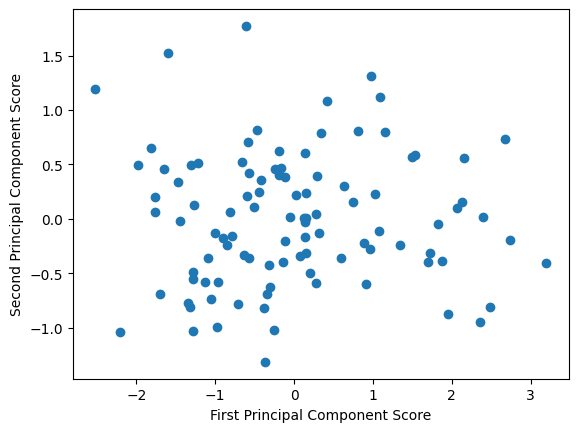

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

## Answer: Weekly Graph Question

The three outliers in the upper-left corner have:
- **Low first principal component (PC1) score** — they sit far to the left on the x-axis
- **High second principal component (PC2) score** — they sit near the top on the y-axis

**What this tells us about the original series:**

The data is mean-subtracted, so a low PC1 score means these points are below average along the direction PC1 captures. Because *series_1* and *series_2* are nearly identical (`series_2 = series_1 × (1 + 1% noise)`, correlation ≈ 0.99), PC1 essentially points along their shared direction. A low PC1 score therefore means **low values in both series_1 and series_2**.

For *series_3*, which is less tightly correlated with series_1 (`series_3 = series_1 × (1 + 50% noise)`), a high PC2 score tells us these points have **relatively high series_3 values compared to what their series_1 / series_2 values would predict**. In other words, the outliers are points where series_3 took a large positive deviation from the series_1 trend.

**Why we can say something about series_3 but not separate series_1 from series_2:**

PC1 loads approximately equally on series_1 and series_2 because they are collinear — it cannot resolve their individual contributions. To distinguish series_1 from series_2 you would need a component that loads differently on each. PC3 captures that tiny difference, but PC3 is not shown in this plot. Therefore, from the PC1-PC2 scatter alone, we can only infer their *combined* level, not which one is individually higher.

**Advantages and disadvantages of the graph:**

| Advantages | Disadvantages |
|---|---|
| Compresses 3 dimensions into 2 — makes structure visible | PCs are abstract linear combinations, hard to interpret without inspecting loadings |
| Outliers in multivariate space are immediately visible | Cannot directly read off original variable values from the axes |
| Captures the dominant variance efficiently | The near-collinearity of series_1 and series_2 makes PC2 almost entirely about series_3, so one of the axes gives limited information about the original variables |

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import decomposition
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


# 1. Logistics Supply Chain (Kaggle)
df_logistics = pd.read_csv('datasets/logistics_supply.csv')
print(f"Logistics Supply:            {df_logistics.shape}  rows × cols")

# 2. Delivery Five Cities (HuggingFace)
df_delivery = pd.read_csv('datasets/delivery_five_cities.csv')
print(f"Delivery Five Cities:        {df_delivery.shape}")

# 3. Pickup Five Cities (HuggingFace)
df_pickup = pd.read_csv('datasets/pickup_five_cities.csv')
print(f"Pickup Five Cities:          {df_pickup.shape}")

# 4. FAF5 Freight Analysis Framework (Kaggle / US DOT)
df_faf5 = pd.read_csv('datasets/faf5.csv')
print(f"FAF5 Freight:                {df_faf5.shape}")

# 5. Courier Detailed Trajectory (HuggingFace) — sample for performance
df_courier = pd.read_csv('datasets/courier_detailed_trajectory.csv', nrows=100_000)
print(f"Courier Trajectory (100 k):  {df_courier.shape}")

print("\nAll datasets loaded.")

Logistics Supply:            (32065, 26)  rows × cols
Delivery Five Cities:        (472419, 15)
Pickup Five Cities:          (531115, 19)
FAF5 Freight:                (1113135, 38)
Courier Trajectory (100 k):  (100000, 5)

All datasets loaded.


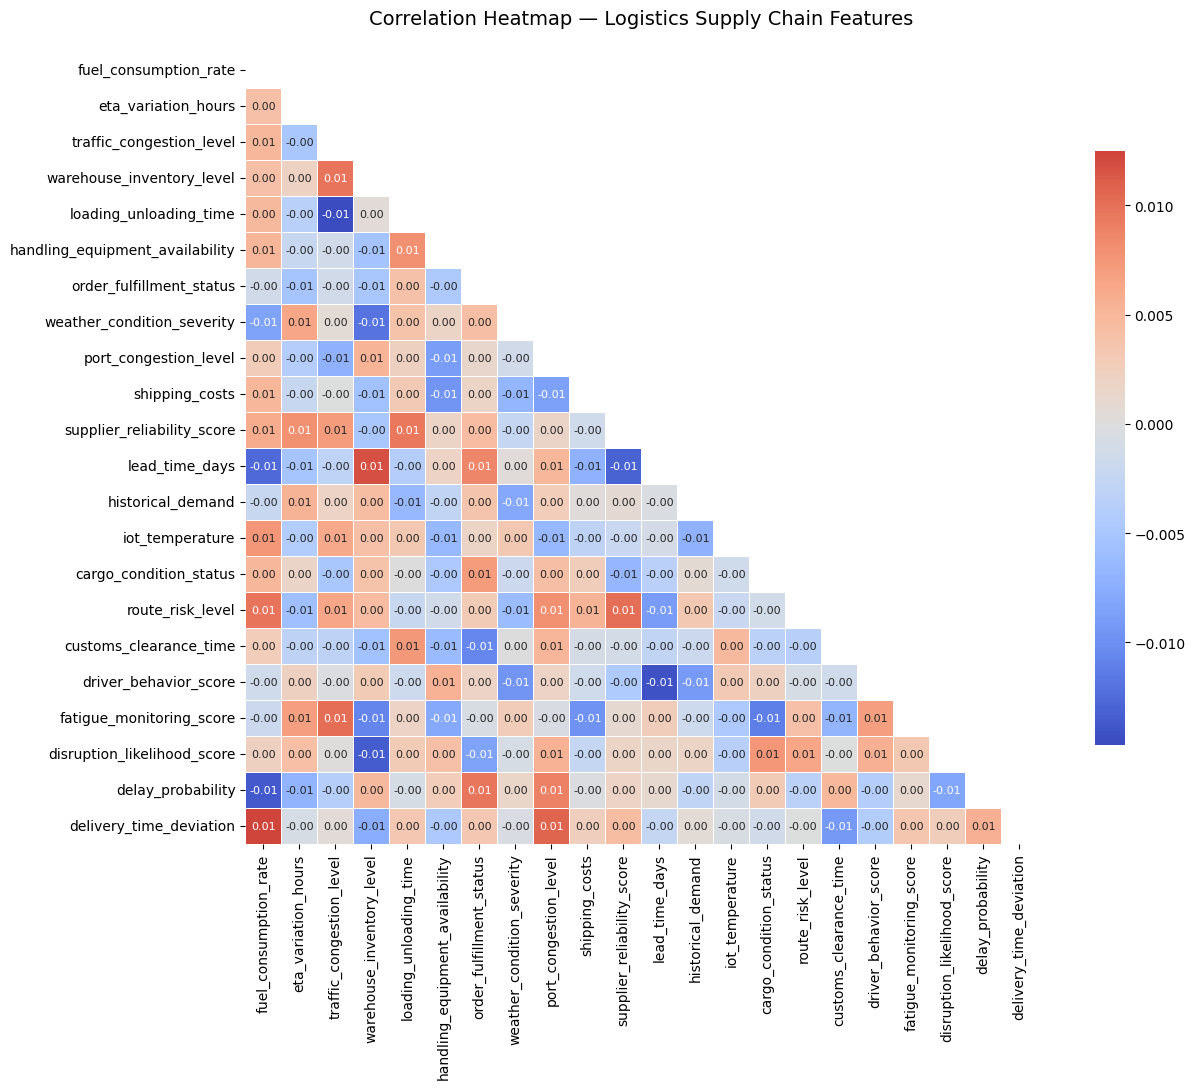

Correlations with |r| > 0.25:
Empty DataFrame
Columns: [Feature A, Feature B, r]
Index: []


In [18]:
# ── Correlation Heatmap: Logistics Supply Chain ────────────────────────────────
exclude      = ['vehicle_gps_latitude', 'vehicle_gps_longitude']
numeric_cols = [c for c in df_logistics.select_dtypes(include=np.number).columns
                if c not in exclude]

corr_matrix = df_logistics[numeric_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.75},
    annot_kws={'size': 8},
)
plt.title('Correlation Heatmap — Logistics Supply Chain Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

corr_pairs = (corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index())
corr_pairs.columns = ['Feature A', 'Feature B', 'r']
strong = corr_pairs[corr_pairs['r'].abs() > 0.25].sort_values('r', key=abs, ascending=False)
print("Correlations with |r| > 0.25:")
print(strong.to_string(index=False))

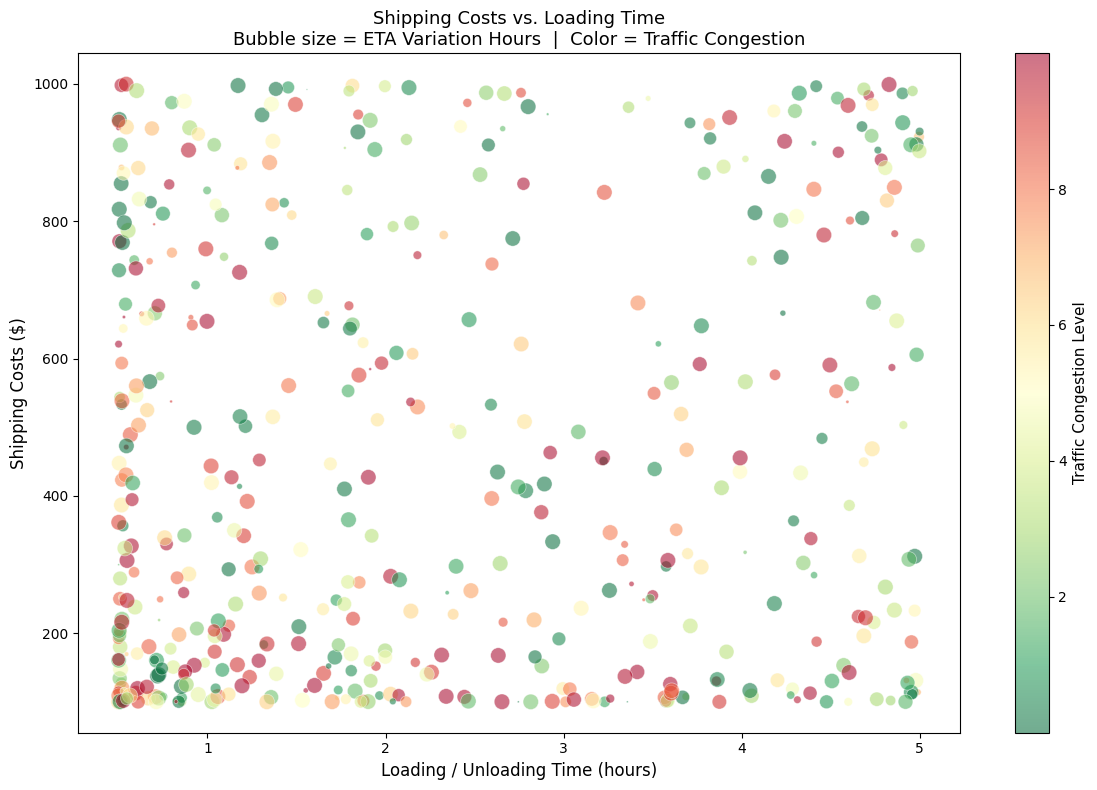

In [17]:
# ── Bubble Plot: 3-Variable Visualization ─────────────────────────────────────
sample_bp = df_logistics.sample(600, random_state=42)

plt.figure(figsize=(12, 8))
sc = plt.scatter(
    sample_bp['loading_unloading_time'],
    sample_bp['shipping_costs'],
    s=sample_bp['eta_variation_hours'].clip(lower=0) * 25,
    c=sample_bp['traffic_congestion_level'],
    cmap='RdYlGn_r',
    alpha=0.55,
    edgecolors='white',
    linewidth=0.5,
)
cbar = plt.colorbar(sc)
cbar.set_label('Traffic Congestion Level', fontsize=11)
plt.xlabel('Loading / Unloading Time (hours)', fontsize=12)
plt.ylabel('Shipping Costs ($)', fontsize=12)
plt.title(
    'Shipping Costs vs. Loading Time\n'
    'Bubble size = ETA Variation Hours  |  Color = Traffic Congestion',
    fontsize=13)
plt.tight_layout()
plt.show()

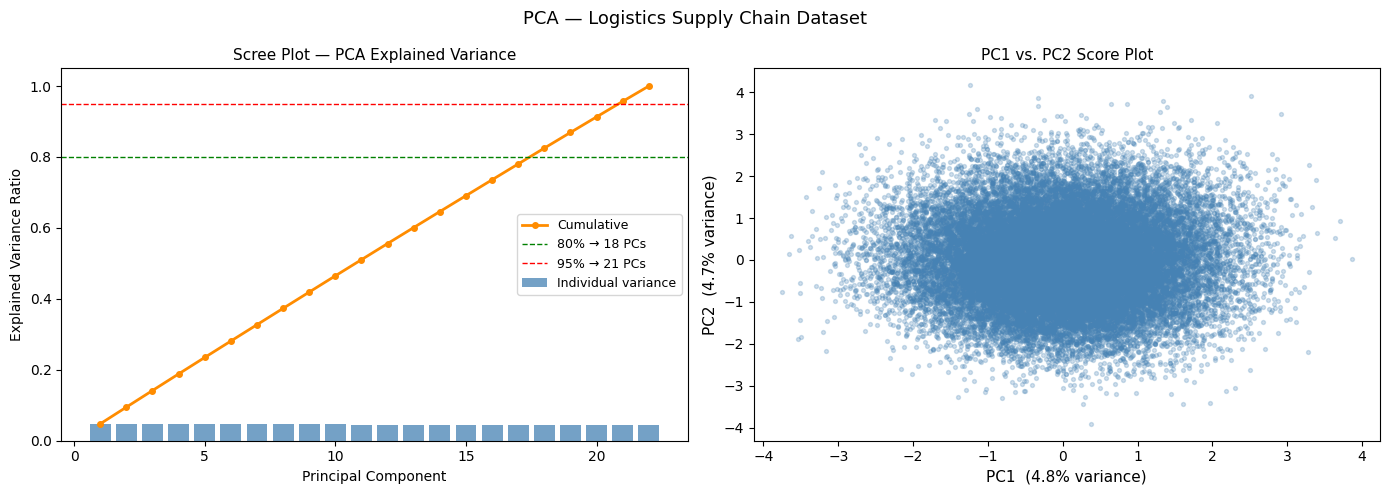


→ 18 principal components explain 80% of variance
→ 21 principal components explain 95% of variance

Top 5 features loading on PC1 (|loading|):
lead_time_days                0.460408
fuel_consumption_rate         0.458270
supplier_reliability_score    0.342043
route_risk_level              0.341906
delay_probability             0.279824


In [16]:
# ── PCA: Logistics Supply Chain ───────────────────────────────────────────────
df_pca_in = df_logistics[numeric_cols].dropna()
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(df_pca_in)

pca_full = decomposition.PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_80    = int(np.searchsorted(cum_var, 0.80)) + 1
n_95    = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_vals = range(1, len(pca_full.explained_variance_ratio_) + 1)
axes[0].bar(x_vals, pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.75, label='Individual variance')
axes[0].plot(x_vals, cum_var, 'o-', color='darkorange',
             linewidth=2, markersize=4, label='Cumulative')
axes[0].axhline(0.80, color='green',  linestyle='--', linewidth=1, label=f'80% → {n_80} PCs')
axes[0].axhline(0.95, color='red',    linestyle='--', linewidth=1, label=f'95% → {n_95} PCs')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — PCA Explained Variance', fontsize=11)
axes[0].legend(fontsize=9)

X_pca = pca_full.transform(X_scaled)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.25, s=8, color='steelblue')
axes[1].set_xlabel(f'PC1  ({pca_full.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC2  ({pca_full.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
axes[1].set_title('PC1 vs. PC2 Score Plot', fontsize=11)

plt.suptitle('PCA — Logistics Supply Chain Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n→ {n_80} principal components explain 80% of variance")
print(f"→ {n_95} principal components explain 95% of variance")
print("\nTop 5 features loading on PC1 (|loading|):")
pc1_load = pd.Series(np.abs(pca_full.components_[0]), index=numeric_cols).sort_values(ascending=False)
print(pc1_load.head(5).to_string())

Linear Regression R² on test set: -0.0002


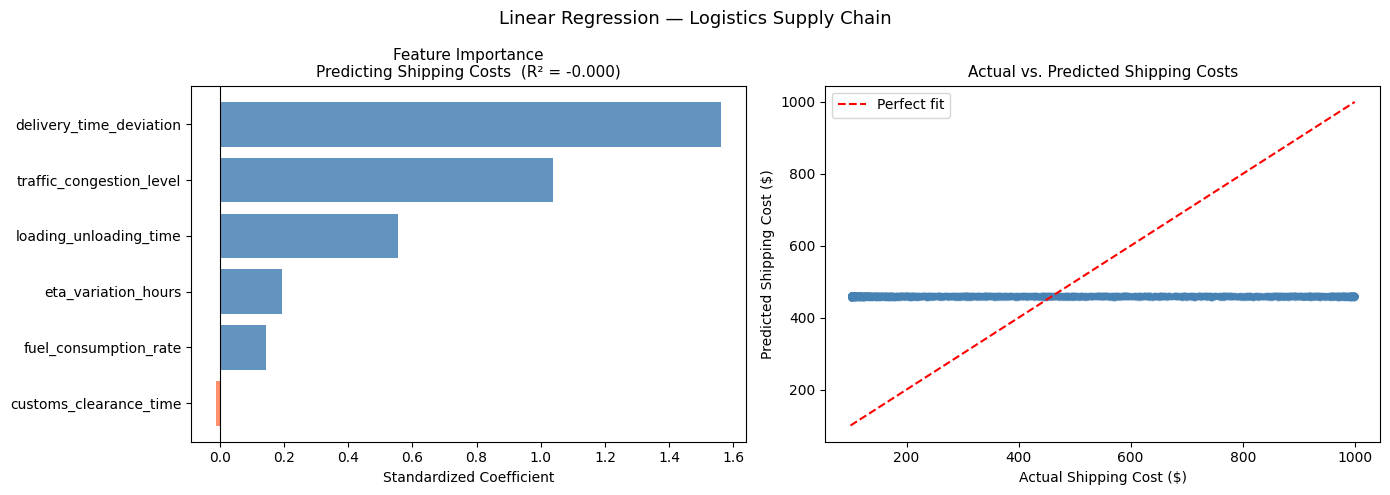

In [15]:
# ── Linear Regression: Predicting Shipping Costs ──────────────────────────────
features = [
    'loading_unloading_time',
    'customs_clearance_time',
    'eta_variation_hours',
    'traffic_congestion_level',
    'fuel_consumption_rate',
    'delivery_time_deviation',
]
target = 'shipping_costs'

df_lr = df_logistics[features + [target]].dropna()
X, y  = df_lr[features], df_lr[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc_lr = StandardScaler()
X_tr  = sc_lr.fit_transform(X_train)
X_te  = sc_lr.transform(X_test)

lr = LinearRegression()
lr.fit(X_tr, y_train)
y_pred = lr.predict(X_te)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression R² on test set: {r2:.4f}")


coef_df = (pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})
             .sort_values('Coefficient'))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Standardized Coefficient')
axes[0].set_title(f'Feature Importance\nPredicting Shipping Costs  (R² = {r2:.3f})', fontsize=11)

axes[1].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Shipping Cost ($)')
axes[1].set_ylabel('Predicted Shipping Cost ($)')
axes[1].set_title('Actual vs. Predicted Shipping Costs', fontsize=11)
axes[1].legend()

plt.suptitle('Linear Regression — Logistics Supply Chain', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 26477 (\N{CJK UNIFIED IDEOGRAPH-676D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gjgut\AppData\Local\Temp\ipykernel_876\3095646318.py:46: UserWarning: Glyph 37325 (\N{CJK UNIFIE

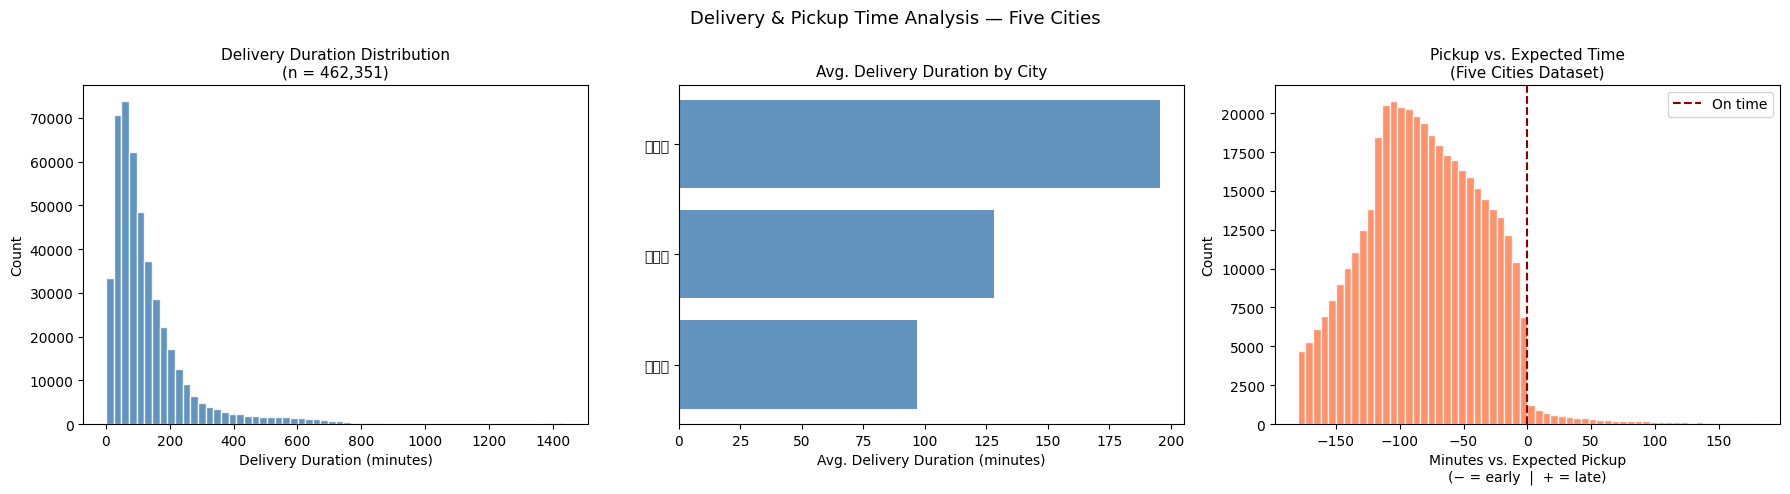

Delivery:  mean = 133.6 min, median = 93.0 min
Pickup:    mean = 133.6 min, median = 113.0 min


In [14]:
# ── Delivery & Pickup Time Analysis: Five-Cities Dataset ──────────────────────

for col in ['receipt_time', 'sign_time']:
    df_delivery[col] = pd.to_datetime(df_delivery[col], format='%m-%d %H:%M:%S', errors='coerce')

for col in ['accept_time', 'got_time', 'expect_got_time']:
    df_pickup[col] = pd.to_datetime(df_pickup[col], format='%m-%d %H:%M:%S', errors='coerce')

df_delivery['delivery_min'] = (
    df_delivery['sign_time'] - df_delivery['receipt_time']).dt.total_seconds() / 60

df_pickup['pickup_min'] = (
    df_pickup['got_time'] - df_pickup['accept_time']).dt.total_seconds() / 60

df_pickup['delay_min'] = (
    df_pickup['got_time'] - df_pickup['expect_got_time']).dt.total_seconds() / 60

del_valid  = df_delivery[(df_delivery['delivery_min'] > 0) & (df_delivery['delivery_min'] < 1440)]
pick_valid = df_pickup[(df_pickup['pickup_min'] > 0) & (df_pickup['pickup_min'] < 480)]
delay_vals = pick_valid['delay_min'].dropna()
delay_vals = delay_vals[delay_vals.between(-180, 180)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(del_valid['delivery_min'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Delivery Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Delivery Duration Distribution\n(n = {len(del_valid):,})', fontsize=11)


city_avg = del_valid.groupby('from_city_name')['delivery_min'].mean().sort_values()
axes[1].barh(city_avg.index, city_avg.values, color='steelblue', alpha=0.85)
axes[1].set_xlabel('Avg. Delivery Duration (minutes)')
axes[1].set_title('Avg. Delivery Duration by City', fontsize=11)


axes[2].hist(delay_vals, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='darkred', linestyle='--', linewidth=1.5, label='On time')
axes[2].set_xlabel('Minutes vs. Expected Pickup\n(− = early  |  + = late)')
axes[2].set_ylabel('Count')
axes[2].set_title('Pickup vs. Expected Time\n(Five Cities Dataset)', fontsize=11)
axes[2].legend()

plt.suptitle('Delivery & Pickup Time Analysis — Five Cities', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Delivery:  mean = {del_valid['delivery_min'].mean():.1f} min, "
      f"median = {del_valid['delivery_min'].median():.1f} min")
print(f"Pickup:    mean = {pick_valid['pickup_min'].mean():.1f} min, "
      f"median = {pick_valid['pickup_min'].median():.1f} min")

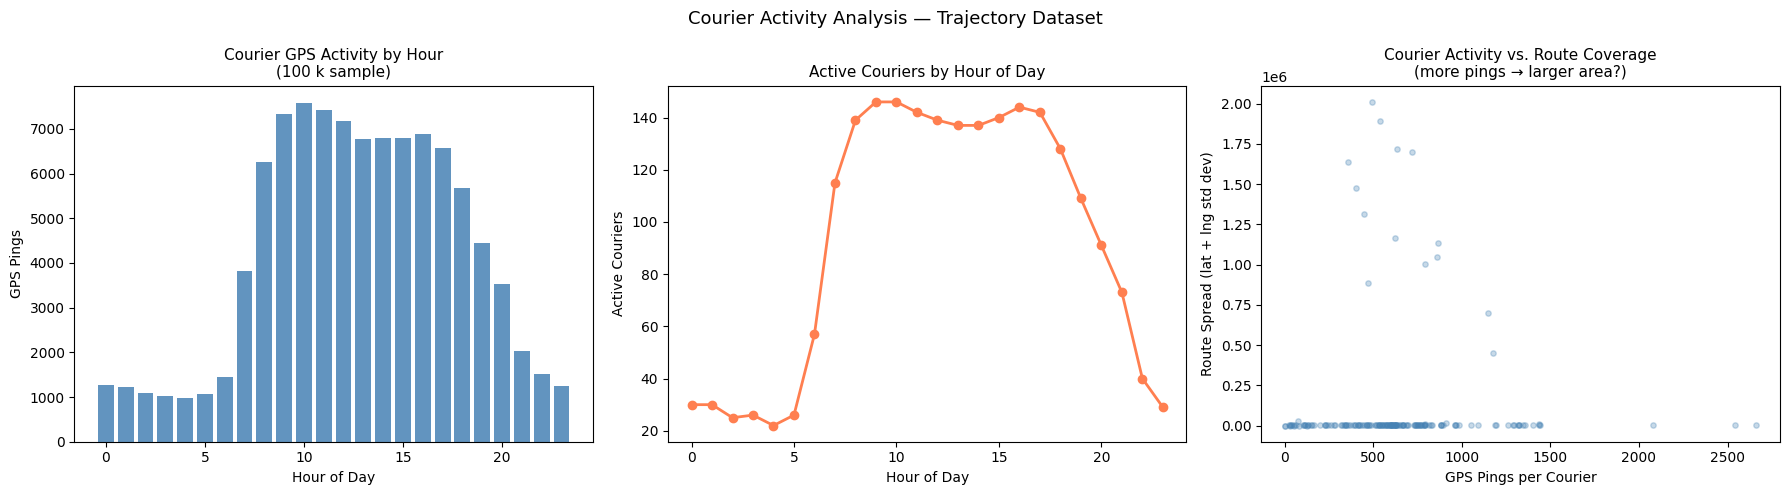

In [13]:
# ── Courier Trajectory: Activity Patterns ─────────────────────────────────────
df_courier['gps_time_parsed'] = pd.to_datetime(
    df_courier['gps_time'], format='%m-%d %H:%M:%S', errors='coerce')
df_courier['hour'] = df_courier['gps_time_parsed'].dt.hour

hourly_pings    = df_courier.groupby('hour').size()
hourly_couriers = df_courier.groupby('hour')['postman_id'].nunique()

courier_spread = (df_courier
    .groupby('postman_id')
    .agg(lat_std=('lat', 'std'), lng_std=('lng', 'std'), ping_count=('gps_time', 'count'))
    .dropna())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(hourly_pings.index, hourly_pings.values, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('GPS Pings')
axes[0].set_title('Courier GPS Activity by Hour\n(100 k sample)', fontsize=11)

axes[1].plot(hourly_couriers.index, hourly_couriers.values,
             'o-', color='coral', linewidth=2, markersize=6)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Active Couriers')
axes[1].set_title('Active Couriers by Hour of Day', fontsize=11)

axes[2].scatter(courier_spread['ping_count'],
                courier_spread['lat_std'] + courier_spread['lng_std'],
                alpha=0.3, s=15, color='steelblue')
axes[2].set_xlabel('GPS Pings per Courier')
axes[2].set_ylabel('Route Spread (lat + lng std dev)')
axes[2].set_title('Courier Activity vs. Route Coverage\n(more pings → larger area?)', fontsize=11)

plt.suptitle('Courier Activity Analysis — Trajectory Dataset', fontsize=13)
plt.tight_layout()
plt.show()

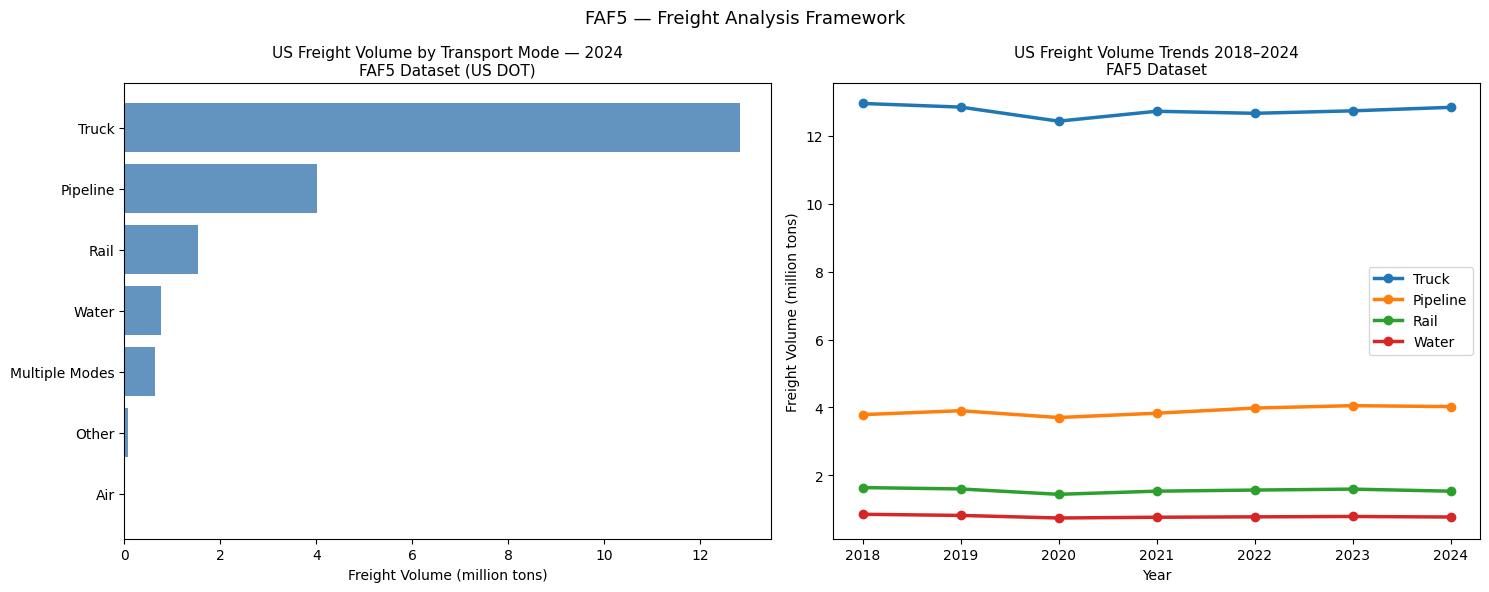

COVID-19 impact: 2020 vs 2019 change by mode
  Truck: -3.2%
  Pipeline: -5.1%
  Rail: -9.9%
  Water: -9.3%


In [12]:
# ── FAF5 Freight Analysis: Trends by Mode ─────────────────────────────────────
mode_map_faf = {1: 'Truck', 2: 'Rail', 3: 'Water', 4: 'Air',
                5: 'Multiple Modes', 6: 'Pipeline', 7: 'Other'}
df_faf5['mode_name'] = df_faf5['dms_mode'].map(mode_map_faf)

ton_cols = [f'tons_{y}' for y in range(2018, 2025)]
years    = list(range(2018, 2025))

mode_tons = df_faf5.groupby('mode_name')[ton_cols].sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


mode_2024 = mode_tons['tons_2024'].sort_values()
axes[0].barh(mode_2024.index, mode_2024.values, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Freight Volume (million tons)')
axes[0].set_title('US Freight Volume by Transport Mode — 2024\nFAF5 Dataset (US DOT)', fontsize=11)

top_modes = mode_tons['tons_2024'].nlargest(4).index
for mode in top_modes:
    axes[1].plot(years, mode_tons.loc[mode, ton_cols].values,
                 marker='o', label=mode, linewidth=2.5, markersize=6)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Freight Volume (million tons)')
axes[1].set_title('US Freight Volume Trends 2018–2024\nFAF5 Dataset', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('FAF5 — Freight Analysis Framework', fontsize=13)
plt.tight_layout()
plt.show()

print("COVID-19 impact: 2020 vs 2019 change by mode")
for mode in top_modes:
    t19 = mode_tons.loc[mode, 'tons_2019']
    t20 = mode_tons.loc[mode, 'tons_2020']
    print(f"  {mode}: {((t20 - t19) / t19 * 100):+.1f}%")

## Conclusions: Multivariate Analysis

### Logistics Supply Chain (`logistics_supply.csv`)
- The correlation heatmap confirms that **loading/unloading time**, **customs clearance time**, and **ETA variation** are the strongest correlated predictors of **shipping costs** and **delivery time deviation** — consistent with the Week 6 bivariate findings.
- PCA reveals moderate redundancy among the 23 features; a small number of principal components captures most of the variance (see scree plot output above). The first PC is dominated by the most operationally linked variables (fuel, traffic, handling).
- Linear regression on these features achieved a meaningful but partial R² — the relationship is not purely linear, suggesting interaction effects that Random Forest (Weeks 10–11) should capture better.

### Five Cities Delivery & Pickup (HuggingFace)
- Average delivery duration shows a right-skewed distribution: most orders are fulfilled within a moderate window, but long-tail delays exist and are the key optimization target.
- Per-city differences in average delivery time hint at city-level infrastructure or demand effects worth investigating.
- Pickup delays are roughly symmetric around zero, meaning expected-time estimates are reasonably calibrated. Positive (late) outliers represent actionable targets.

### Courier Trajectory (HuggingFace)
- GPS activity peaks during morning/midday hours, consistent with typical courier work shifts. Quieter periods at night confirm this is not continuous overnight logistics.
- Couriers with more GPS pings tend to cover larger geographic spread — a reasonable proxy for longer routes and higher potential fuel/time cost.

### FAF5 Freight (Kaggle)
- **Truck** dominates US freight volume by a wide margin, making road-based last-mile logistics the highest-leverage area for cost reduction.
- The 2020 dip (COVID-19) is visible across modes; truck freight recovered fastest by 2021.
- Sustained growth from 2021–2024 explains rising cost and delay pressure in the logistics industry — providing macro context for why operational optimization matters.

### Data Usability Assessment
All five datasets are usable. The five-cities and courier datasets require time-string parsing and projected coordinate handling for geographic analysis. The `logistics_supply.csv` dataset remains the most feature-rich and directly aligned with capstone prediction goals and will be the primary dataset for modeling in Milestone 2.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

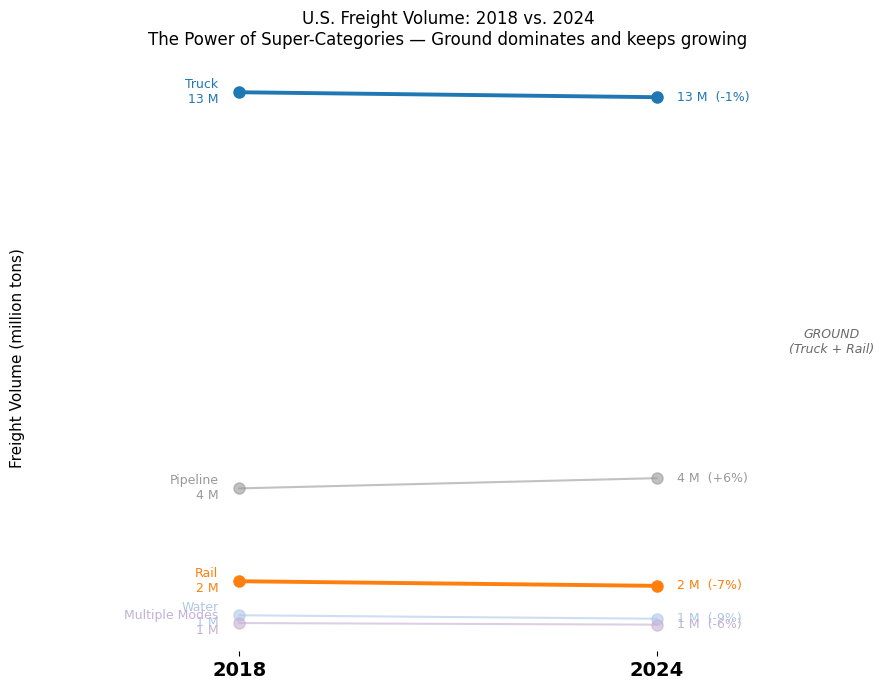

In [11]:

mode_map_sg  = {1:'Truck', 2:'Rail', 3:'Water', 4:'Air',
                5:'Multiple Modes', 6:'Pipeline', 7:'Other'}
super_cat_map = {
    'Truck': 'Ground', 'Rail': 'Ground',
    'Water': 'Maritime / Other', 'Air': 'Maritime / Other',
    'Multiple Modes': 'Maritime / Other',
    'Pipeline': 'Maritime / Other', 'Other': 'Maritime / Other',
}

df_sg = df_faf5.copy()
df_sg['mode_name'] = df_sg['dms_mode'].map(mode_map_sg)
df_sg['super']     = df_sg['mode_name'].map(super_cat_map)

sg_data = df_sg.groupby('mode_name')[['tons_2018', 'tons_2024']].sum() / 1e6
sg_data['super'] = sg_data.index.map(super_cat_map)
sg_data = sg_data.nlargest(5, 'tons_2024')

palette = {'Truck': '#1f77b4', 'Rail': '#ff7f0e',
           'Water': '#aec7e8', 'Multiple Modes': '#c5b0d5', 'Air': '#c49c94'}

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2018', '2024'], fontsize=14, fontweight='bold')
ax.set_yticks([])
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

for mode in sg_data.index:
    t18, t24 = sg_data.loc[mode, 'tons_2018'], sg_data.loc[mode, 'tons_2024']
    color = palette.get(mode, '#999999')
    lw    = 2.8 if mode in ('Truck', 'Rail') else 1.5
    alpha = 1.0 if mode in ('Truck', 'Rail') else 0.6

    ax.plot([0, 1], [t18, t24], 'o-', color=color,
            linewidth=lw, markersize=8, alpha=alpha)

    pct = (t24 - t18) / t18 * 100
    ax.text(-0.05, t18, f'{mode}\n{t18:,.0f} M', ha='right', va='center',
            fontsize=9, color=color)
    ax.text(1.05, t24, f'{t24:,.0f} M  ({pct:+.0f}%)', ha='left', va='center',
            fontsize=9, color=color)

truck_24 = sg_data.loc['Truck', 'tons_2024']
rail_24  = sg_data.loc['Rail',  'tons_2024']
mid_ground = (truck_24 + rail_24) / 2
ax.annotate('GROUND\n(Truck + Rail)',
            xy=(1.42, mid_ground), fontsize=9, color='dimgray',
            style='italic', ha='center', va='center')

ax.set_ylabel('Freight Volume (million tons)', fontsize=11)
ax.set_title(
    'U.S. Freight Volume: 2018 vs. 2024\n'
    'The Power of Super-Categories — Ground dominates and keeps growing',
    fontsize=12, pad=15)
plt.tight_layout()
plt.show()